<a href="https://colab.research.google.com/github/shirin6767saleh/code-/blob/Fnew/testtestselectedcolumn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-1849059953.py:85: RuntimeWarning: overflow encountered in scalar divide
  orth_defect = prod_norms / abs(np.linalg.det(V))
/tmp/ipython-input-1849059953.py:85: RuntimeWarning: divide by zero encountered in scalar divide
  orth_defect = prod_norms / abs(np.linalg.det(V))
/usr/local/lib/python3.11/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.11/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


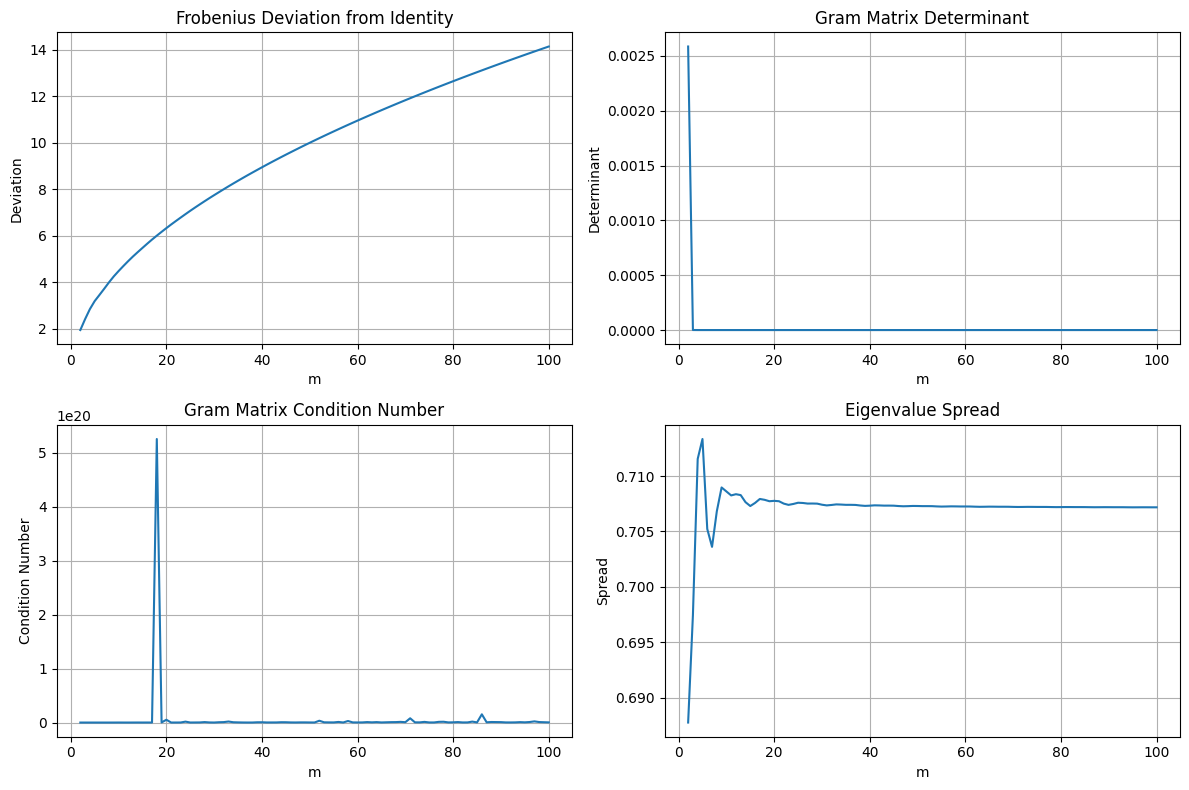

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Range of m values from 2 to 100
m_values = range(2, 101)

# Lists to store the computed metrics for each m
frob_devs = []
gram_dets = []
gram_conds = []
eig_spreads = []
eig_ratios = []
orth_defects = []
avg_abs_cos_list = []

for m in m_values:
    N = 4 * m
    t = N - 1
    w = np.exp((-2j * np.pi) / N)

    # Construct matrix Gt
    Gt = np.zeros((N, N), dtype=complex)
    for k in range(N):
        for l in range(N):
            Gt[k, l] = (1 / np.sqrt(N)) * w ** ((k - t/2) * (l - t/2))

    # Construct matrices Ct and St
    Ct = np.zeros((N, N))
    St = np.zeros((N, N))
    for k in range(N):
        for l in range(N):
            angle = (k - t/2) * (l - t/2) * (2 * np.pi / N)
            Ct[k, l] = (2 / np.sqrt(N)) * np.cos(angle)
            St[k, l] = (2 / np.sqrt(N)) * np.sin(angle)

    # Identity and flip matrices
    I = np.eye(N)
    J = np.flipud(I)

    m_idx = m  # index for slicing
    # Construct matrices P1, Pm1, Pt, Pt1
    P1 =  Ct + I + J
    Pm1 = Ct - I - J
    Pt =  St - I + J
    Pt1 = St + I - J

    # Extract columns
    slice1 = P1[:, m_idx:2 * m_idx]
    slice2 = Pm1[:, m_idx:2 * m_idx]
    slice3 = Pt[:, m_idx:2 * m_idx]
    slice4 = Pt1[:, m_idx:2 * m_idx]

    # Function to normalize a single column
    def normalize_column(col):
        return col / np.linalg.norm(col)

    # Function to normalize each column of a matrix separately
    def normalize_columns(matrix):
        return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

    # Normalize each slice individually
    slice1_norm = normalize_columns(slice1)
    slice2_norm = normalize_columns(slice2)
    slice3_norm = normalize_columns(slice3)
    slice4_norm = normalize_columns(slice4)

    # Concatenate all normalized slices to form matrix V
    V = np.concatenate([slice1_norm, slice2_norm, slice3_norm, slice4_norm], axis=1)

    # Compute Gram matrix
    G = V.T @ V
    N_cols = V.shape[1]

    # Compute metrics
    frob_deviation = np.linalg.norm(G - np.eye(N_cols), 'fro')
    gram_det = np.linalg.det(G)
    gram_cond = np.linalg.cond(G)

    eig_vals = np.linalg.eigvals(G)
    eig_spread = np.sqrt(np.mean((eig_vals - 1) ** 2))
    eig_ratio = np.max(eig_vals) / np.min(eig_vals)

    norms = np.sqrt(np.diag(G))
    prod_norms = np.prod(norms)
    orth_defect = prod_norms / abs(np.linalg.det(V))

    # Average absolute cosine of angles between vectors
    norm_matrix = np.outer(norms, norms)
    cos_matrix = np.abs(G) / norm_matrix
    np.fill_diagonal(cos_matrix, np.nan)
    avg_abs_cos = np.nanmean(cos_matrix)

    # Store the metrics for each m
    frob_devs.append(frob_deviation)
    gram_dets.append(gram_det)
    gram_conds.append(gram_cond)
    eig_spreads.append(eig_spread)
    eig_ratios.append(eig_ratio)
    orth_defects.append(orth_defect)
    avg_abs_cos_list.append(avg_abs_cos)

# Plot the results
plt.figure(figsize=(12, 8))

# Frobenius deviation plot
plt.subplot(2, 2, 1)
plt.plot(m_values, frob_devs, label='Frobenius Deviation')
plt.xlabel('m')
plt.ylabel('Deviation')
plt.title('Frobenius Deviation from Identity')
plt.grid(True)

# Gram determinant plot
plt.subplot(2, 2, 2)
plt.plot(m_values, gram_dets, label='Gram Determinant')
plt.xlabel('m')
plt.ylabel('Determinant')
plt.title('Gram Matrix Determinant')
plt.grid(True)

# Gram condition number plot
plt.subplot(2, 2, 3)
plt.plot(m_values, gram_conds, label='Condition Number')
plt.xlabel('m')
plt.ylabel('Condition Number')
plt.title('Gram Matrix Condition Number')
plt.grid(True)

# Eigenvalue spread plot
plt.subplot(2, 2, 4)
plt.plot(m_values, eig_spreads, label='Eigenvalue Spread')
plt.xlabel('m')
plt.ylabel('Spread')
plt.title('Eigenvalue Spread')
plt.grid(True)

plt.tight_layout()
plt.show()


/tmp/ipython-input-2863213818.py:85: RuntimeWarning: overflow encountered in scalar divide
  orth_defect = prod_norms / abs(np.linalg.det(V))
/tmp/ipython-input-2863213818.py:85: RuntimeWarning: divide by zero encountered in scalar divide
  orth_defect = prod_norms / abs(np.linalg.det(V))


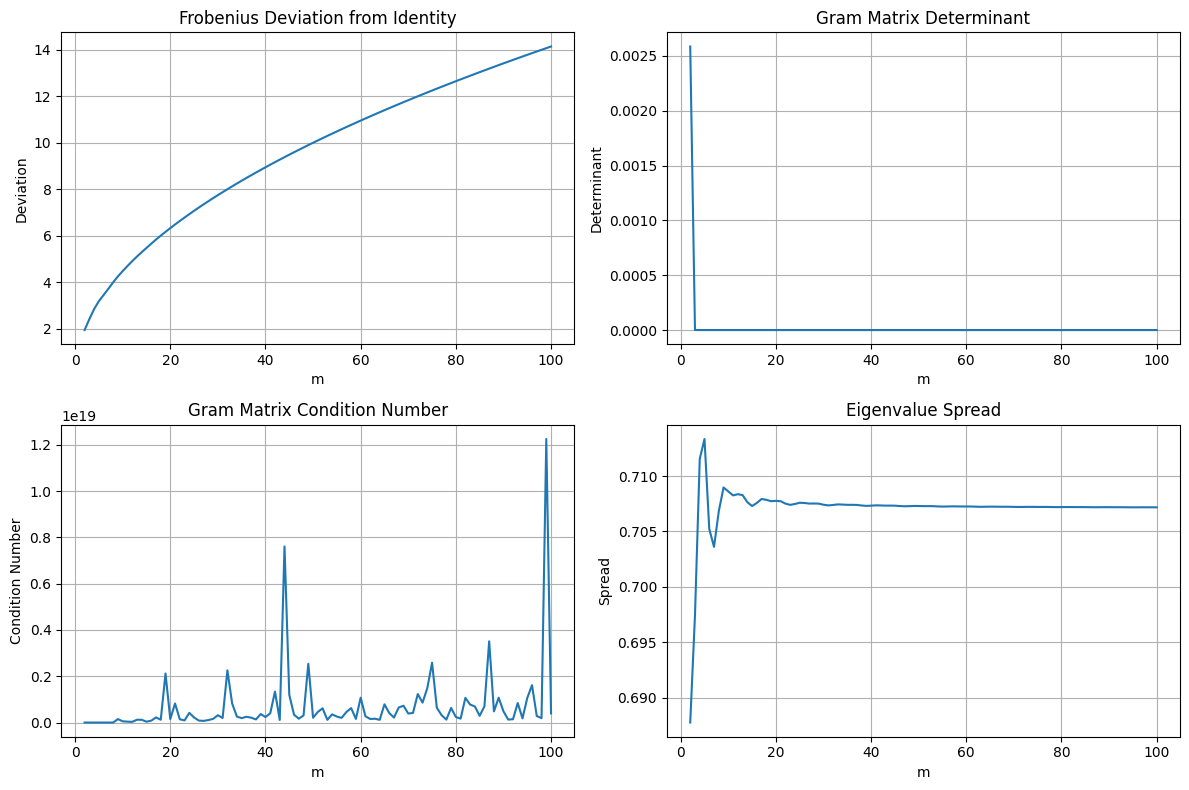

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Range of m values from 2 to 100
m_values = range(2, 101)

# Lists to store the computed metrics for each m
frob_devs = []
gram_dets = []
gram_conds = []
eig_spreads = []
eig_ratios = []
orth_defects = []
avg_abs_cos_list = []

for m in m_values:
    N = 4 * m
    t = N - 1
    w = np.exp((-2j * np.pi) / N)

    # Construct matrix Gt
    Gt = np.zeros((N, N), dtype=complex)
    for k in range(N):
        for l in range(N):
            Gt[k, l] = (1 / np.sqrt(N)) * w ** ((k - t/2) * (l - t/2))

    # Construct matrices Ct and St
    Ct = np.zeros((N, N))
    St = np.zeros((N, N))
    for k in range(N):
        for l in range(N):
            angle = (k - t/2) * (l - t/2) * (2 * np.pi / N)
            Ct[k, l] = (2 / np.sqrt(N)) * np.cos(angle)
            St[k, l] = (2 / np.sqrt(N)) * np.sin(angle)

    # Identity and flip matrices
    I = np.eye(N)
    J = np.flipud(I)

    m_idx = m  # index for slicing
    # Construct matrices P1, Pm1, Pt, Pt1
    P1 =  Ct + I + J
    Pm1 = Ct - I - J
    Pt =  St - I + J
    Pt1 = St + I - J

    # Extract columns
    slice1 = P1[:, :m]
    slice2 = Pm1[:, :m]
    slice3 = Pt[:, :m]
    slice4 = Pt1[:, :m]

    # Function to normalize a single column
    def normalize_column(col):
        return col / np.linalg.norm(col)

    # Function to normalize each column of a matrix separately
    def normalize_columns(matrix):
        return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

    # Normalize each slice individually
    slice1_norm = normalize_columns(slice1)
    slice2_norm = normalize_columns(slice2)
    slice3_norm = normalize_columns(slice3)
    slice4_norm = normalize_columns(slice4)

    # Concatenate all normalized slices to form matrix V
    V = np.concatenate([slice1_norm, slice2_norm, slice3_norm, slice4_norm], axis=1)

    # Compute Gram matrix
    G = V.T @ V
    N_cols = V.shape[1]

    # Compute metrics
    frob_deviation = np.linalg.norm(G - np.eye(N_cols), 'fro')
    gram_det = np.linalg.det(G)
    gram_cond = np.linalg.cond(G)

    eig_vals = np.linalg.eigvals(G)
    eig_spread = np.sqrt(np.mean((eig_vals - 1) ** 2))
    eig_ratio = np.max(eig_vals) / np.min(eig_vals)

    norms = np.sqrt(np.diag(G))
    prod_norms = np.prod(norms)
    orth_defect = prod_norms / abs(np.linalg.det(V))

    # Average absolute cosine of angles between vectors
    norm_matrix = np.outer(norms, norms)
    cos_matrix = np.abs(G) / norm_matrix
    np.fill_diagonal(cos_matrix, np.nan)
    avg_abs_cos = np.nanmean(cos_matrix)

    # Store the metrics for each m
    frob_devs.append(frob_deviation)
    gram_dets.append(gram_det)
    gram_conds.append(gram_cond)
    eig_spreads.append(eig_spread)
    eig_ratios.append(eig_ratio)
    orth_defects.append(orth_defect)
    avg_abs_cos_list.append(avg_abs_cos)

# Plot the results
plt.figure(figsize=(12, 8))

# Frobenius deviation plot
plt.subplot(2, 2, 1)
plt.plot(m_values, frob_devs, label='Frobenius Deviation')
plt.xlabel('m')
plt.ylabel('Deviation')
plt.title('Frobenius Deviation from Identity')
plt.grid(True)

# Gram determinant plot
plt.subplot(2, 2, 2)
plt.plot(m_values, gram_dets, label='Gram Determinant')
plt.xlabel('m')
plt.ylabel('Determinant')
plt.title('Gram Matrix Determinant')
plt.grid(True)

# Gram condition number plot
plt.subplot(2, 2, 3)
plt.plot(m_values, gram_conds, label='Condition Number')
plt.xlabel('m')
plt.ylabel('Condition Number')
plt.title('Gram Matrix Condition Number')
plt.grid(True)

# Eigenvalue spread plot
plt.subplot(2, 2, 4)
plt.plot(m_values, eig_spreads, label='Eigenvalue Spread')
plt.xlabel('m')
plt.ylabel('Spread')
plt.title('Eigenvalue Spread')
plt.grid(True)

plt.tight_layout()
plt.show()


/tmp/ipython-input-2004203065.py:85: RuntimeWarning: overflow encountered in scalar divide
  orth_defect = prod_norms / abs(np.linalg.det(V))
/tmp/ipython-input-2004203065.py:85: RuntimeWarning: divide by zero encountered in scalar divide
  orth_defect = prod_norms / abs(np.linalg.det(V))
/usr/local/lib/python3.11/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.11/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


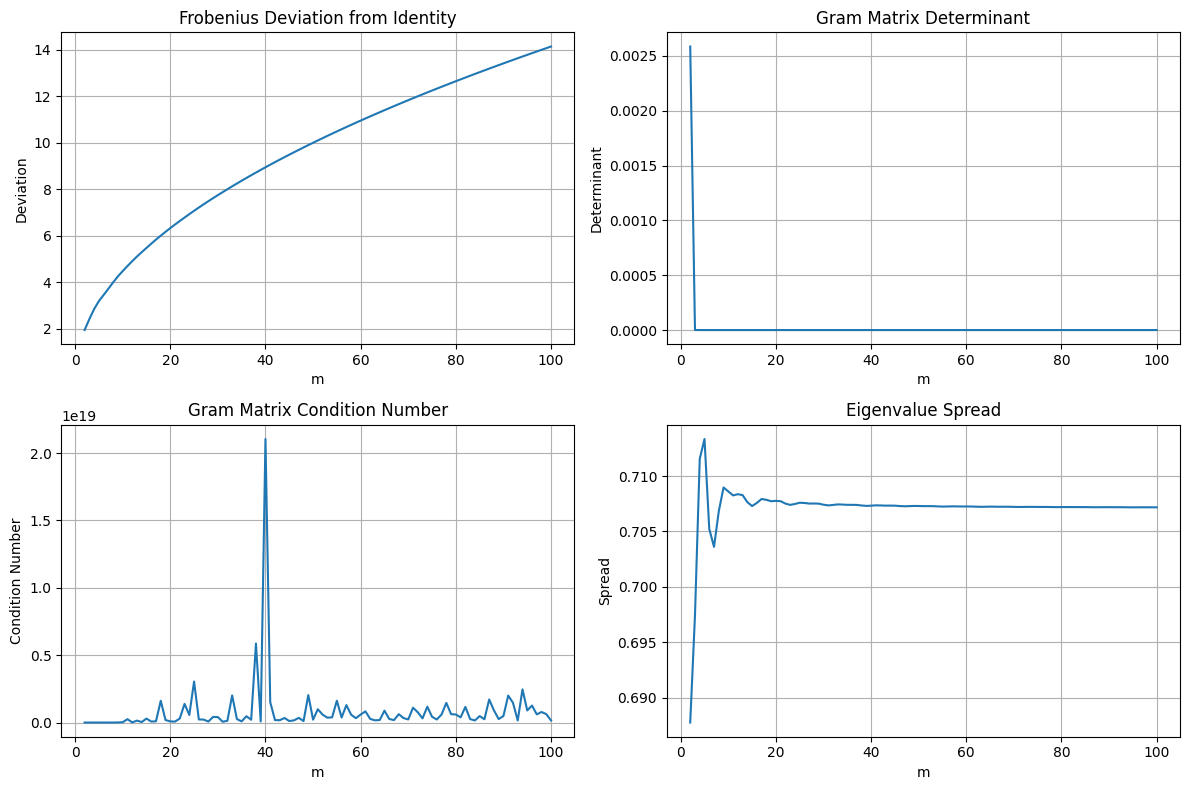

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Range of m values from 2 to 100
m_values = range(2, 101)

# Lists to store the computed metrics for each m
frob_devs = []
gram_dets = []
gram_conds = []
eig_spreads = []
eig_ratios = []
orth_defects = []
avg_abs_cos_list = []

for m in m_values:
    N = 4 * m
    t = N - 1
    w = np.exp((-2j * np.pi) / N)

    # Construct matrix Gt
    Gt = np.zeros((N, N), dtype=complex)
    for k in range(N):
        for l in range(N):
            Gt[k, l] = (1 / np.sqrt(N)) * w ** ((k - t/2) * (l - t/2))

    # Construct matrices Ct and St
    Ct = np.zeros((N, N))
    St = np.zeros((N, N))
    for k in range(N):
        for l in range(N):
            angle = (k - t/2) * (l - t/2) * (2 * np.pi / N)
            Ct[k, l] = (2 / np.sqrt(N)) * np.cos(angle)
            St[k, l] = (2 / np.sqrt(N)) * np.sin(angle)

    # Identity and flip matrices
    I = np.eye(N)
    J = np.flipud(I)

    m_idx = m  # index for slicing
    # Construct matrices P1, Pm1, Pt, Pt1
    P1 =  Ct + I + J
    Pm1 = Ct - I - J
    Pt =  St - I + J
    Pt1 = St + I - J

    # Extract columns
    slice1 = P1[:, 2*m:3*m]
    slice2 = Pm1[:, 2*m:3*m]
    slice3 = Pt[:, 2*m:3*m]
    slice4 = Pt1[:, 2*m:3*m]

    # Function to normalize a single column
    def normalize_column(col):
        return col / np.linalg.norm(col)

    # Function to normalize each column of a matrix separately
    def normalize_columns(matrix):
        return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

    # Normalize each slice individually
    slice1_norm = normalize_columns(slice1)
    slice2_norm = normalize_columns(slice2)
    slice3_norm = normalize_columns(slice3)
    slice4_norm = normalize_columns(slice4)

    # Concatenate all normalized slices to form matrix V
    V = np.concatenate([slice1_norm, slice2_norm, slice3_norm, slice4_norm], axis=1)

    # Compute Gram matrix
    G = V.T @ V
    N_cols = V.shape[1]

    # Compute metrics
    frob_deviation = np.linalg.norm(G - np.eye(N_cols), 'fro')
    gram_det = np.linalg.det(G)
    gram_cond = np.linalg.cond(G)

    eig_vals = np.linalg.eigvals(G)
    eig_spread = np.sqrt(np.mean((eig_vals - 1) ** 2))
    eig_ratio = np.max(eig_vals) / np.min(eig_vals)

    norms = np.sqrt(np.diag(G))
    prod_norms = np.prod(norms)
    orth_defect = prod_norms / abs(np.linalg.det(V))

    # Average absolute cosine of angles between vectors
    norm_matrix = np.outer(norms, norms)
    cos_matrix = np.abs(G) / norm_matrix
    np.fill_diagonal(cos_matrix, np.nan)
    avg_abs_cos = np.nanmean(cos_matrix)

    # Store the metrics for each m
    frob_devs.append(frob_deviation)
    gram_dets.append(gram_det)
    gram_conds.append(gram_cond)
    eig_spreads.append(eig_spread)
    eig_ratios.append(eig_ratio)
    orth_defects.append(orth_defect)
    avg_abs_cos_list.append(avg_abs_cos)

# Plot the results
plt.figure(figsize=(12, 8))

# Frobenius deviation plot
plt.subplot(2, 2, 1)
plt.plot(m_values, frob_devs, label='Frobenius Deviation')
plt.xlabel('m')
plt.ylabel('Deviation')
plt.title('Frobenius Deviation from Identity')
plt.grid(True)

# Gram determinant plot
plt.subplot(2, 2, 2)
plt.plot(m_values, gram_dets, label='Gram Determinant')
plt.xlabel('m')
plt.ylabel('Determinant')
plt.title('Gram Matrix Determinant')
plt.grid(True)

# Gram condition number plot
plt.subplot(2, 2, 3)
plt.plot(m_values, gram_conds, label='Condition Number')
plt.xlabel('m')
plt.ylabel('Condition Number')
plt.title('Gram Matrix Condition Number')
plt.grid(True)

# Eigenvalue spread plot
plt.subplot(2, 2, 4)
plt.plot(m_values, eig_spreads, label='Eigenvalue Spread')
plt.xlabel('m')
plt.ylabel('Spread')
plt.title('Eigenvalue Spread')
plt.grid(True)

plt.tight_layout()
plt.show()


/tmp/ipython-input-2724482856.py:85: RuntimeWarning: divide by zero encountered in scalar divide
  orth_defect = prod_norms / abs(np.linalg.det(V))


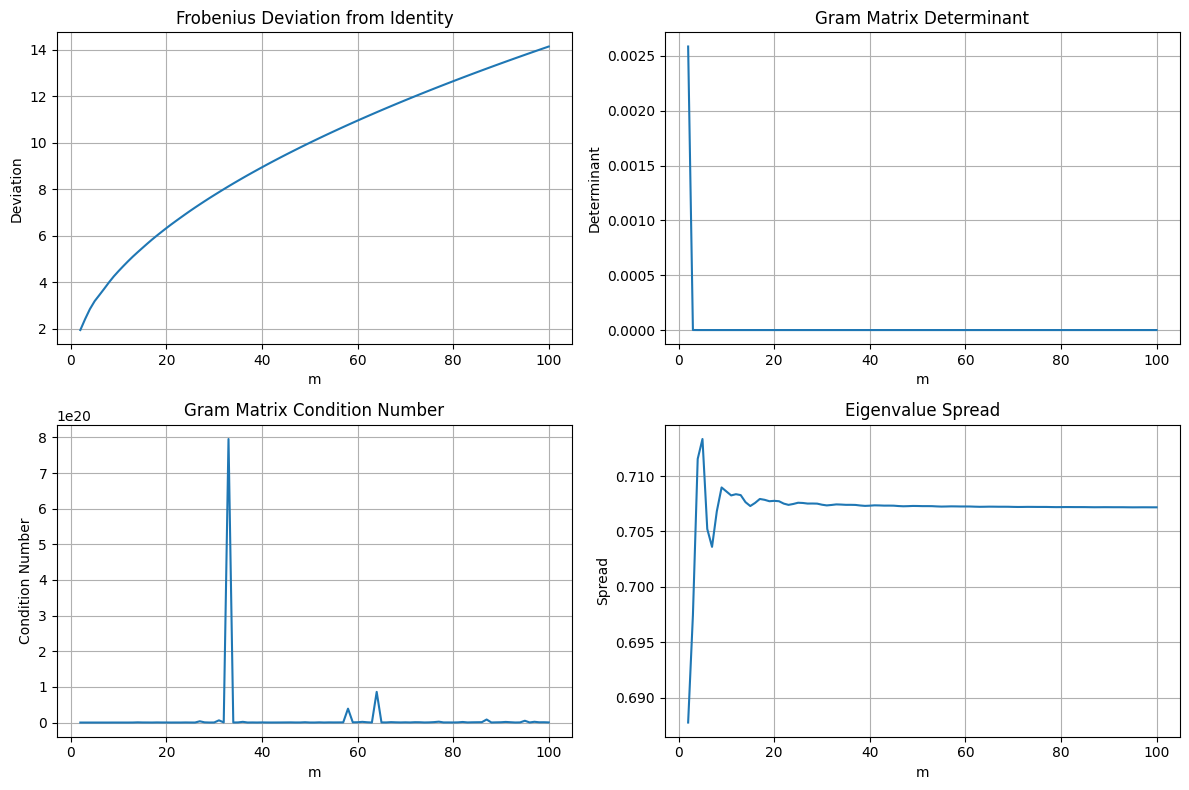

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Range of m values from 2 to 100
m_values = range(2, 101)

# Lists to store the computed metrics for each m
frob_devs = []
gram_dets = []
gram_conds = []
eig_spreads = []
eig_ratios = []
orth_defects = []
avg_abs_cos_list = []

for m in m_values:
    N = 4 * m
    t = N - 1
    w = np.exp((-2j * np.pi) / N)

    # Construct matrix Gt
    Gt = np.zeros((N, N), dtype=complex)
    for k in range(N):
        for l in range(N):
            Gt[k, l] = (1 / np.sqrt(N)) * w ** ((k - t/2) * (l - t/2))

    # Construct matrices Ct and St
    Ct = np.zeros((N, N))
    St = np.zeros((N, N))
    for k in range(N):
        for l in range(N):
            angle = (k - t/2) * (l - t/2) * (2 * np.pi / N)
            Ct[k, l] = (2 / np.sqrt(N)) * np.cos(angle)
            St[k, l] = (2 / np.sqrt(N)) * np.sin(angle)

    # Identity and flip matrices
    I = np.eye(N)
    J = np.flipud(I)

    m_idx = m  # index for slicing
    # Construct matrices P1, Pm1, Pt, Pt1
    P1 =  Ct + I + J
    Pm1 = Ct - I - J
    Pt =  St - I + J
    Pt1 = St + I - J

    # Extract columns
    slice1 = P1[:, 3*m:4*m]
    slice2 = Pm1[:, 3*m:4*m]
    slice3 = Pt[:, 3*m:4*m]
    slice4 = Pt1[:, 3*m:4*m]

    # Function to normalize a single column
    def normalize_column(col):
        return col / np.linalg.norm(col)

    # Function to normalize each column of a matrix separately
    def normalize_columns(matrix):
        return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

    # Normalize each slice individually
    slice1_norm = normalize_columns(slice1)
    slice2_norm = normalize_columns(slice2)
    slice3_norm = normalize_columns(slice3)
    slice4_norm = normalize_columns(slice4)

    # Concatenate all normalized slices to form matrix V
    V = np.concatenate([slice1_norm, slice2_norm, slice3_norm, slice4_norm], axis=1)

    # Compute Gram matrix
    G = V.T @ V
    N_cols = V.shape[1]

    # Compute metrics
    frob_deviation = np.linalg.norm(G - np.eye(N_cols), 'fro')
    gram_det = np.linalg.det(G)
    gram_cond = np.linalg.cond(G)

    eig_vals = np.linalg.eigvals(G)
    eig_spread = np.sqrt(np.mean((eig_vals - 1) ** 2))
    eig_ratio = np.max(eig_vals) / np.min(eig_vals)

    norms = np.sqrt(np.diag(G))
    prod_norms = np.prod(norms)
    orth_defect = prod_norms / abs(np.linalg.det(V))

    # Average absolute cosine of angles between vectors
    norm_matrix = np.outer(norms, norms)
    cos_matrix = np.abs(G) / norm_matrix
    np.fill_diagonal(cos_matrix, np.nan)
    avg_abs_cos = np.nanmean(cos_matrix)

    # Store the metrics for each m
    frob_devs.append(frob_deviation)
    gram_dets.append(gram_det)
    gram_conds.append(gram_cond)
    eig_spreads.append(eig_spread)
    eig_ratios.append(eig_ratio)
    orth_defects.append(orth_defect)
    avg_abs_cos_list.append(avg_abs_cos)

# Plot the results
plt.figure(figsize=(12, 8))

# Frobenius deviation plot
plt.subplot(2, 2, 1)
plt.plot(m_values, frob_devs, label='Frobenius Deviation')
plt.xlabel('m')
plt.ylabel('Deviation')
plt.title('Frobenius Deviation from Identity')
plt.grid(True)

# Gram determinant plot
plt.subplot(2, 2, 2)
plt.plot(m_values, gram_dets, label='Gram Determinant')
plt.xlabel('m')
plt.ylabel('Determinant')
plt.title('Gram Matrix Determinant')
plt.grid(True)

# Gram condition number plot
plt.subplot(2, 2, 3)
plt.plot(m_values, gram_conds, label='Condition Number')
plt.xlabel('m')
plt.ylabel('Condition Number')
plt.title('Gram Matrix Condition Number')
plt.grid(True)

# Eigenvalue spread plot
plt.subplot(2, 2, 4)
plt.plot(m_values, eig_spreads, label='Eigenvalue Spread')
plt.xlabel('m')
plt.ylabel('Spread')
plt.title('Eigenvalue Spread')
plt.grid(True)

plt.tight_layout()
plt.show()
